# noise test on generated data
We often plot r_train (correlation of model fit to vell mean visual response data) vs respcorr (repeatability, correlation of cell response to the same stimuli) as it shows model fit performance and overfitting on the cell population.

This is a very basic calculation to show how data would look like with ideal model fit just affected by random noise. 

Conclusion: in our case the model fit is far from ideal. 

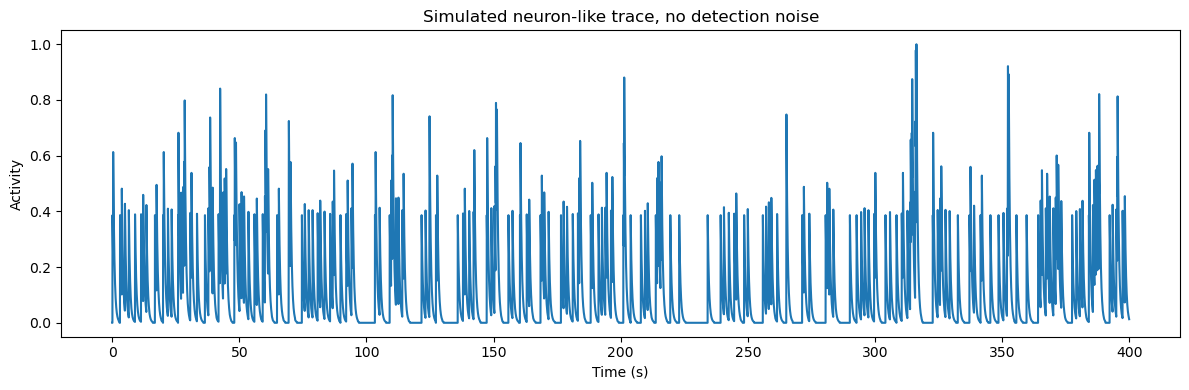

In [1]:
#ground truth
import numpy as np
import matplotlib.pyplot as plt

# random seed
rng = np.random.default_rng(0)

n_timepoints = 12_000
fps = 30
t = np.arange(n_timepoints) / fps

# sparse neural events
event_rate = 0.02
events = rng.random(n_timepoints) < event_rate

# calcium-like exponential decay kernel
tau = 0.5  # seconds
kernel_t = np.arange(0, 5 * tau, 1 / fps)
kernel = np.exp(-kernel_t / tau)

# noiseless calcium trace
trace = np.convolve(events.astype(float), kernel, mode="full")[:n_timepoints]

# normalize
base_trace = trace / trace.max()

plt.figure(figsize=(12, 4))
plt.plot(t, base_trace)
plt.xlabel("Time (s)")
plt.ylabel("Activity")
plt.title("Simulated neuron-like trace, no detection noise")
plt.tight_layout()
plt.show()

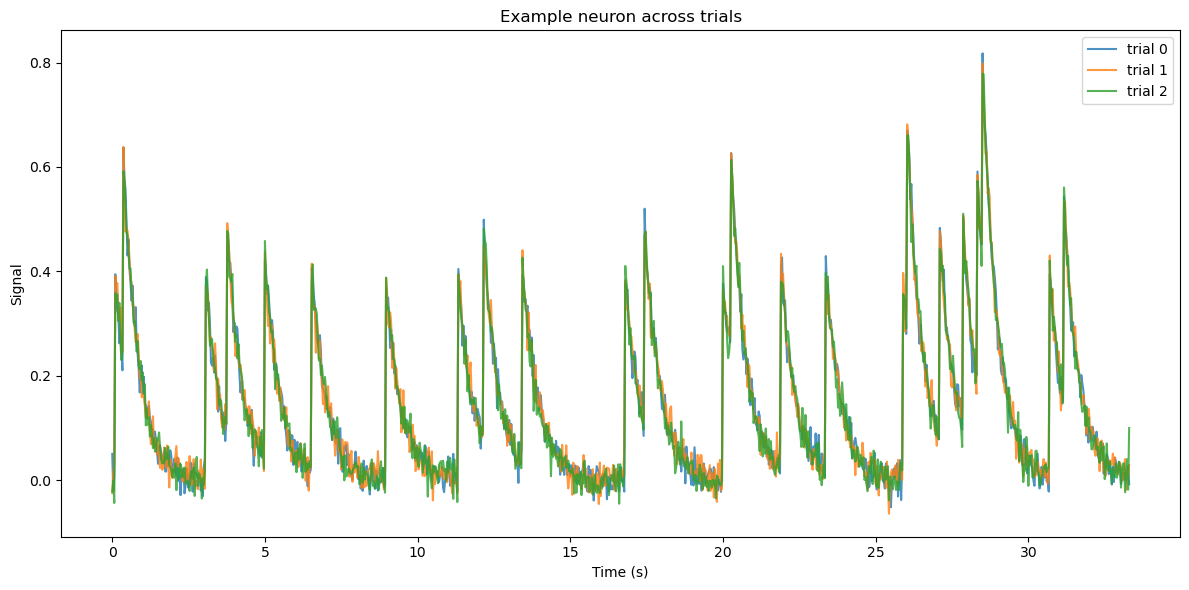

(3, 12000, 100)


In [2]:
# generating noisy data
# ---------------- parameters ----------------
n_trials = 3
n_neurons = 100

# neuron-specific noise levels
noise_levels = np.linspace(0.02, 1.0, n_neurons)
noise_levels = np.logspace(np.log10(0.02), np.log10(10), n_neurons)

# ---------------- generate dataset ----------------
# shape: (n_trials, n_timepoints, n_neurons)
spks = np.empty(
    (n_trials, n_timepoints, n_neurons),
    dtype=np.float32
)

for ni in range(n_neurons):

    noise_std = noise_levels[ni]

    for tr in range(n_trials):

        noise = rng.normal(
            loc=0,
            scale=noise_std,
            size=n_timepoints
        )

        spks[tr, :, ni] = base_trace + noise

# ---------------- example plot ----------------
plt.figure(figsize=(12, 6))

for tr in range(n_trials):
    plt.plot(
        t[:1000],
        spks[tr, :1000, 0],
        alpha=0.8,
        label=f"trial {tr}"
    )

plt.xlabel("Time (s)")
plt.ylabel("Signal")
plt.title("Example neuron across trials")
plt.legend()

plt.tight_layout()
plt.show()

print(spks.shape)

In [3]:
from waven2.analysis_utils import compute_respcorr_split_half, ccmax_from_cchalf_simple

# compute repetability by trial
respcorr=compute_respcorr_split_half(spks)

# " We define as “visually responsive neurons” all neurons with a repeatability higher than 0.2"
responsive_neurons = np.where(respcorr > 0.2 )
print(f"Number of visually responsive neurons (repeatability > 0.2): {np.count_nonzero(responsive_neurons)} out of {len(respcorr)} ({np.count_nonzero(responsive_neurons)/len(respcorr)*100:.1f}%)")

Computing split-half correlation per neuron: 100%|██████████| 100/100 [00:00<00:00, 2217.68it/s]

Number of visually responsive neurons (repeatability > 0.2): 45 out of 100 (45.0%)


Text(0.5, 0, 'Repeatability (respcorr)')

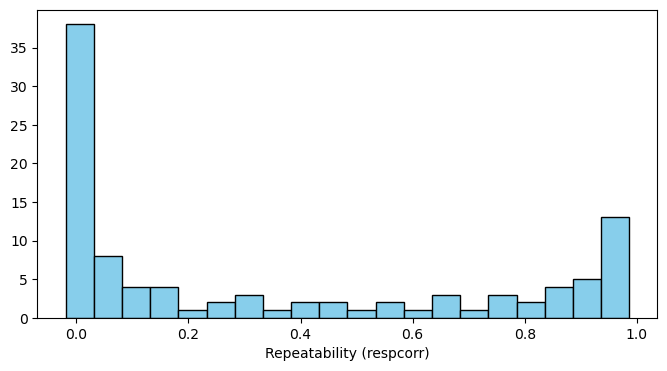

In [4]:
plt.figure(figsize=(8, 4))
plt.hist(respcorr, bins=20, color="skyblue", edgecolor="black")
plt.xlabel("Repeatability (respcorr)")

Text(0, 0.5, 'Noise level (std)')

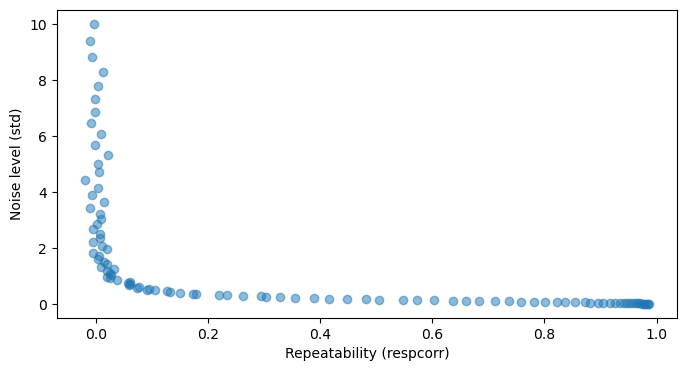

In [5]:
plt.figure(figsize=(8, 4))
plt.scatter(respcorr, noise_levels, alpha=0.5)
plt.xlabel("Repeatability (respcorr)")
plt.ylabel("Noise level (std)")


In [6]:
train_split=0.85
train_split_index=int(n_timepoints*train_split)
trace_train=spks[:, :train_split_index, :]
trace_test=spks[:, train_split_index:, :]
train_base_trace=base_trace[:train_split_index]
test_base_trace=base_trace[train_split_index:]

In [7]:
# generate r_train as the correlation of base_trace with the mean response across trials in the training set for each neuron
r_train = np.empty((n_neurons,))
for ni in range(n_neurons):
    mean_response_train = trace_train[:, :, ni].mean(axis=0)
    r_train[ni] = np.corrcoef(train_base_trace, mean_response_train)[0, 1]    

# generate r_test as the correlation of base_trace with the mean response across trials in the test set for each neuron
r_test = np.empty((n_neurons,))
for ni in range(n_neurons):
    mean_response_test = trace_test[:, :, ni].mean(axis=0)
    r_test[ni] = np.corrcoef(test_base_trace, mean_response_test)[0, 1]

(0.0, 1.0)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


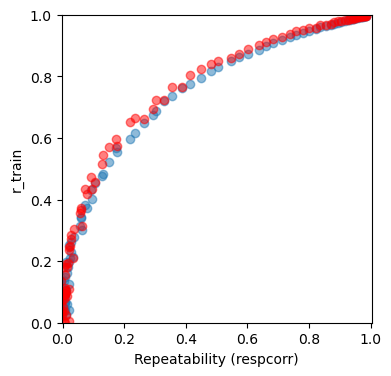

In [8]:
plt.figure(figsize=(4, 4))
plt.scatter(respcorr, r_train, alpha=0.5)
plt.scatter(respcorr, r_test, alpha=0.5, color="red")
plt.xlabel("Repeatability (respcorr)")
plt.ylabel("r_train")

#set axis equal
plt.axis("equal")
plt.ylim(0, 1)
plt.xlim(0, 1)


## split-half reliability estimates

In [9]:
# ccmax_from_cchalf_simple is in waven2.analysis_utils
CCmax=ccmax_from_cchalf_simple(respcorr)

Using CCmax instead of respcorr, we get linear relationship for r_train and r_test, as expected. 


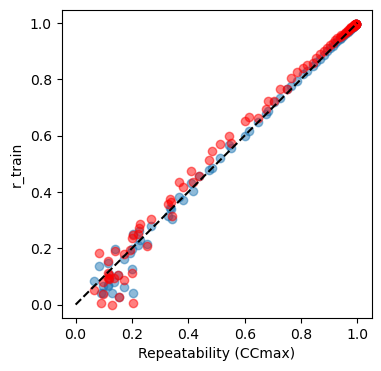

In [10]:


plt.figure(figsize=(4, 4))
plt.scatter(CCmax, r_train, alpha=0.5)
plt.scatter(CCmax, r_test, alpha=0.5, color="red")
plt.xlabel("Repeatability (CCmax)")
plt.ylabel("r_train")


#set axis equal
plt.axis("equal")
plt.plot([0, 1], [0, 1], color="black", linestyle="--")

print("Using CCmax instead of respcorr, we get linear relationship for r_train and r_test, as expected. ")

In [11]:
# accounting for uneven splits in ccmax_from_cchalf
def ccmax_from_cchalf(CChalf, n_trials):
    """
    Convert split-half response correlation to CCmax **calculating unusual splits**.

    For even n_trials this reduces to:
        CCmax = sqrt(2*CChalf / (1 + CChalf))

    For odd n_trials it uses the actual near-half split sizes:
        1 vs 2 for 3 trials
        2 vs 3 for 5 trials
    """
    CChalf = np.asarray(CChalf, dtype=float)

    m = n_trials // 2
    n = n_trials - m

    CCmax = np.full_like(CChalf, np.nan, dtype=float)

    valid = np.isfinite(CChalf) & (CChalf > 0) & (CChalf < 1)

    c = CChalf[valid]
    c2 = c ** 2

    a = 1 / m
    b = 1 / n

    # Estimate signal/noise ratio q = signal_power / single_trial_noise_power
    # from correlation between m-trial and n-trial averages.
    numerator = c2 * (a + b) + np.sqrt(
        c2**2 * (a + b)**2 + 4 * (1 - c2) * c2 * a * b
    )
    denominator = 2 * (1 - c2)
    q = numerator / denominator

    # Reliability of the full N-trial averaged response.
    rel_N = q / (q + 1 / n_trials)

    CCmax[valid] = np.sqrt(rel_N)

    # Near-perfect case.
    CCmax[CChalf >= 1] = 1.0

    return CCmax

ccmax_corr=ccmax_from_cchalf(respcorr, n_trials)


print("difference between ccmax_from_cchalf and ccmax_from_cchalf_simple is small for odd n_trials, and zero for even n_trials:")
print(f"n_trials = {n_trials}, max difference = {np.nanmax(np.abs(ccmax_corr - CCmax))}")
print("We will use the simplified version throughout.")

difference between ccmax_from_cchalf and ccmax_from_cchalf_simple is small for odd n_trials, and zero for even n_trials:
n_trials = 3, max difference = 0.014016292648823314
We will use the simplified version throughout.


Text(0, 0.5, 'CCmax from cchalf_simple')

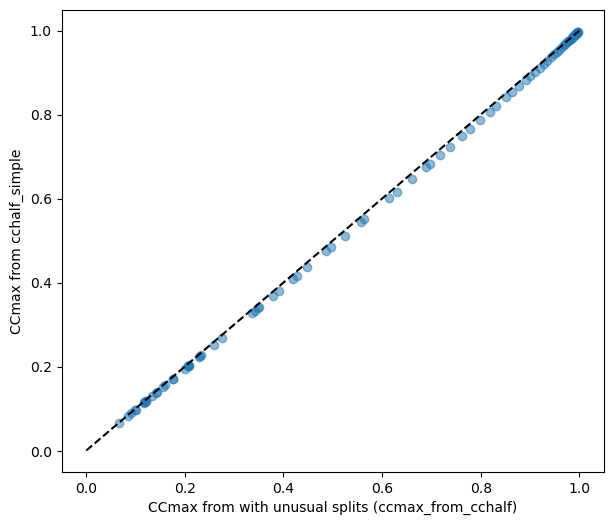

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(ccmax_corr, CCmax, alpha=0.5, label="CCmax from cchalf simplified")
ax.plot([0, 1], [0, 1], color="black", linestyle="--")
ax.set_xlabel("CCmax from with unusual splits (ccmax_from_cchalf)")
ax.set_ylabel("CCmax from cchalf_simple")

## variance-based reliability estimate

In [13]:
# variance-based reliability estimate

from waven2.analysis_utils import ccmax_schoppe_from_trials


CCmax_schoppe=ccmax_schoppe_from_trials(spks)

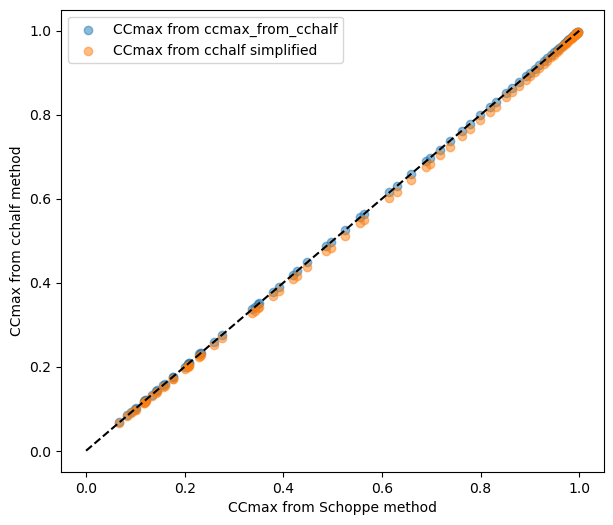

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(CCmax_schoppe, ccmax_corr, alpha=0.5, label="CCmax from ccmax_from_cchalf")
ax.scatter(CCmax_schoppe, CCmax, alpha=0.5, label="CCmax from cchalf simplified")
ax.plot([0, 1], [0, 1], color="black", linestyle="--")
ax.set_xlabel("CCmax from Schoppe method")
ax.set_ylabel("CCmax from cchalf method")
ax.legend()

The two are almost identical, however on real data, split-half calculation gives larger estimate:


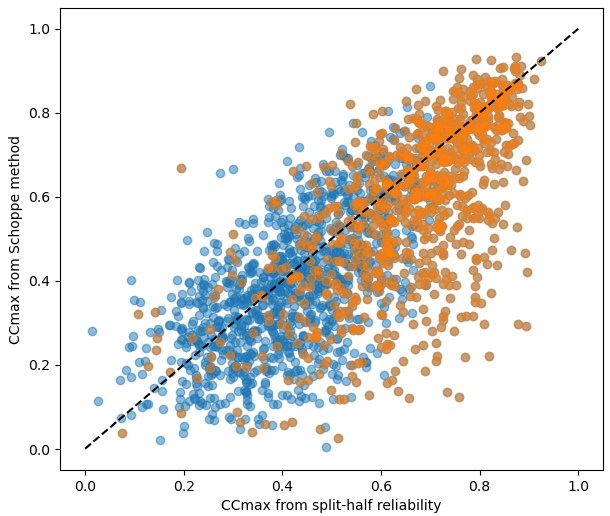

about half of the difference between the two come from gain differences over trals.

(0.0, 1.0)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


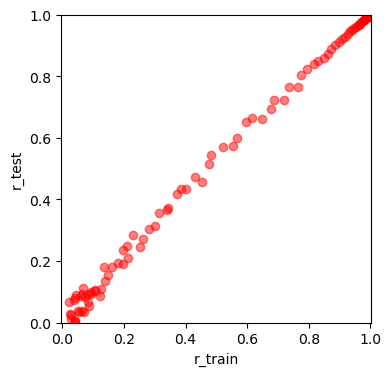

In [15]:
plt.figure(figsize=(4, 4))
plt.scatter(r_train, r_test, alpha=0.5, color="red")
plt.xlabel("r_train")
plt.ylabel("r_test")

#set axis equal
plt.axis("equal")
plt.ylim(0, 1)
plt.xlim(0, 1)

In [16]:
print(f"Done. n_neurons: {n_neurons}, n_trials: {n_trials}, n_timepoints: {n_timepoints}")

Done. n_neurons: 100, n_trials: 3, n_timepoints: 12000
